#  Hybrid Music Recommendation System
## Notebook 2: Modeling and Recommendation

###  Section 1: Content-Based Filtering
This section focuses on building a content-based recommender system using the audio features in the dataset. The goal is to recommend songs that are sonically similar to a given track by computing cosine similarity between audio features.


##  Step 1: Load Data and Libraries
Import necessary libraries for data handling, modeling, evaluation, and visualization. Load the pre-cleaned Spotify dataset and take a random sample of 10,000 for processing.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.neighbors import NearestNeighbors
from xgboost import XGBRegressor

df = pd.read_csv('cleaned_spotify_data.csv')

df_sampled = df.sample(n=10000, random_state=42).reset_index(drop=True)


df.head()



,id,name,artists,duration_ms,release_date,year,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,mode,key,popularity,explicit,release_year
0,2ZywW3VyVx6rrlrX75n3JB,"""40"" - Live",['U2'],226200,1983-08-20,1983,0.100201,0.275304,0.684,0.0145,0.946,0.788655,0.052549,0.586171,0.279,1,8,41,0,1983
1,6DdWA7D1o5TU2kXWyCLcch,"""40"" - Remastered 2008",['U2'],157667,1983-02-28,1983,0.185743,0.375506,0.545,0.5820,0.183,0.795134,0.031946,0.615820,0.310,1,8,37,0,1983
2,3vMmwsAiLDCfyc1jl76lQE,"""40"" - Remastered 2008",['U2'],157667,1983-02-28,1983,0.185743,0.375506,0.545,0.5820,0.183,0.795134,0.031946,0.615820,0.310,1,8,35,0,1983
3,25Sd73fleKUVPNqITPZkn1,"""45""",['The Gaslight Anthem'],202493,2012-01-01,2012,0.000699,0.318826,0.970,0.0000,0.277,0.867391,0.106139,0.729515,0.423,1,8,48,0,2012
4,6CvreUbryAmXAUo35wuCQJ,"""A"" You're Adorable",['Brian Hyland'],151680,2061-01-01,1961,0.483936,0.622470,0.375,0.0000,0.111,0.778709,0.033195,0.453601,0.922,0,0,44,0,2061


# Show correlation between features

##  Step 2: Visualize Feature Correlations
Generate a heatmap of numeric features to examine linear relationships between variables, helping identify redundancy or important signals.

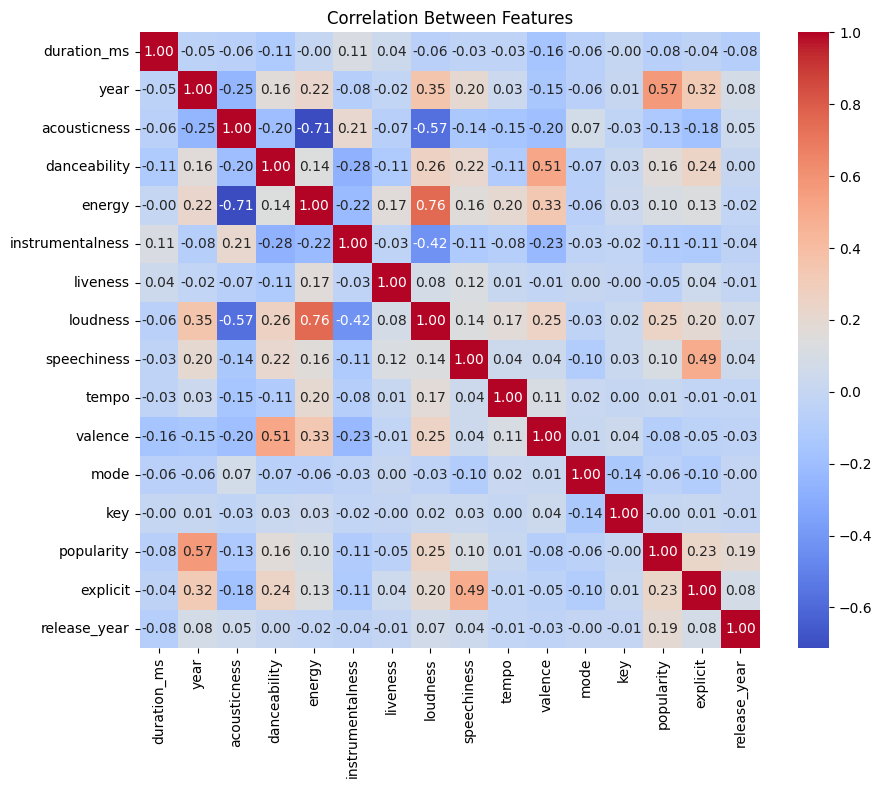

In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Features")
plt.show()

Conclusion output- These two features — danceability and explicit — show the strongest linear relationships with your target popularity. 

Explicit has a mild positive correlation (+0.23) with popularity.

But since it's not a strong predictor, and we already have better audio-based features like danceability and energy, it’s not critical unless we are optimizing further.

##  Step 3: Prepare Features and Target Variable
Define the set of features to be used in modeling and isolate the target variable (⁠ popularity ⁠). Also, prepare a feature matrix for recommendation using cosine similarity.


In [4]:

features = ['acousticness', 'danceability', 'energy', 'instrumentalness',
            'liveness', 'loudness', 'speechiness', 'tempo', 'valence', 'release_year']
target = 'popularity'

X = df[features]
y = df[target]


In [5]:
feature_matrix = df_sampled[features].to_numpy()

##  Step 4: Setup Content-Based Recommender
Fit a cosine similarity-based Nearest Neighbors model to enable content-driven music recommendations.

In [6]:
nn_model = NearestNeighbors(metric='cosine', algorithm='brute')
nn_model.fit(feature_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

##  Step 5: Define Hybrid Recommendation Function
Blend content similarity with predicted popularity scores using a weighted formula to deliver personalized recommendations.

In [7]:
def hybrid_recommend(song_index, n=5, alpha=0.7):
    distances, indices = nm_model.kneighbors([feature_matrix[song_index]], n_neighbors=n+1)
    distances = distances[0][1:]
    indices = indices[0][1:]

    hybrid_scores = []
    for i, dist in zip(indices, distances):
        content_score = 1 - dist
        ml_score = df_sampled.iloc[i]['predicted_popularity'] / 100
        final_score = alpha * ml_score + (1 - alpha) * content_score
        hybrid_scores.append((i, final_score))

    top = sorted(hybrid_scores, key=lambda x: x[1], reverse=True)
    rec_indices = [idx for idx, _ in top[:n]]
    return df_sampled.iloc[rec_indices][['name', 'release_date', 'popularity', 'predicted_popularity']]


# Create a simple high/low popularity target for classification

In [8]:
y_class = (y >= y.median()).astype(int)

## Step 6: Train-Test Split and Model Initialization
Split data into training and testing sets (80/20). Train both Random Forest and XGBoost models to predict song popularity.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Train two models - Random Forest and XGBoost

## Step 7: Hyperparameter Tuning
Apply Randomized Search to optimize parameters for both models based on Mean Squared Error using cross-validation.

In [10]:
rf = RandomForestRegressor(random_state=42)
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)


rf_search = RandomizedSearchCV(
    rf,
    param_distributions={
        'n_estimators': [100, 200],
        'max_depth': [6, 10, 15],
        'min_samples_split': [2, 5],
    },
    n_iter=5, cv=3, random_state=42, scoring='neg_mean_squared_error')

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions={
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 10],
        'learning_rate': [0.05, 0.1],
    },
    n_iter=5, cv=3, random_state=42, scoring='neg_mean_squared_error')

rf_search.fit(X_train, y_train)
xgb_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

##  Step 8: Evaluate Model Performance
Measure RMSE, MAE, and R² for model accuracy. Convert predictions into classes (popular vs. not) and evaluate with confusion matrices, classification reports, and ROC curves.

In [11]:
def evaluate(model, X, y, name):
    pred = model.predict(X)
    print(f"{name} Results:")
    print("RMSE:", np.sqrt(mean_squared_error(y, pred)))
    print("MAE:", mean_absolute_error(y, pred))
    print("R²:", r2_score(y, pred))
    return pred

rf_preds = evaluate(best_rf, X_test, y_test, "Random Forest")
xgb_preds = evaluate(best_xgb, X_test, y_test, "XGBoost")


Random Forest Results:
RMSE: 8.499520572837556
MAE: 6.691973482100008
R²: 0.4719561991748886
XGBoost Results:
RMSE: 8.479134924326974
MAE: 6.667662143707275
R²: 0.4744861125946045


##  Step 9: Feature Importance
Visualize the importance of each feature in predicting popularity for both XGBoost and Random Forest.

In [12]:
rf_class = (rf_preds >= y.median()).astype(int)
xgb_class = (xgb_preds >= y.median()).astype(int)

print("\nRandom Forest Classification:")
print(classification_report(y_test_cls, rf_class))

print("\nXGBoost Classification:")
print(classification_report(y_test_cls, xgb_class))


Random Forest Classification:
              precision    recall  f1-score   support

           0       0.71      0.80      0.75      9187
           1       0.78      0.68      0.73      9450

    accuracy                           0.74     18637
   macro avg       0.74      0.74      0.74     18637
weighted avg       0.74      0.74      0.74     18637


XGBoost Classification:
              precision    recall  f1-score   support

           0       0.71      0.80      0.75      9187
           1       0.78      0.68      0.73      9450

    accuracy                           0.74     18637
   macro avg       0.74      0.74      0.74     18637
weighted avg       0.74      0.74      0.74     18637



# Show confusion matrix and ROC curve

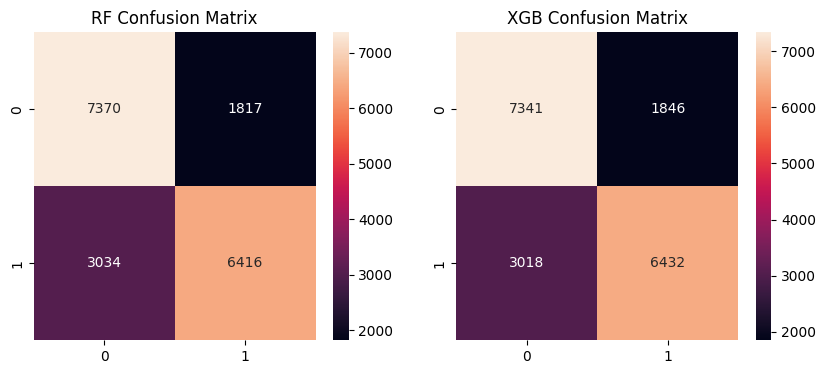

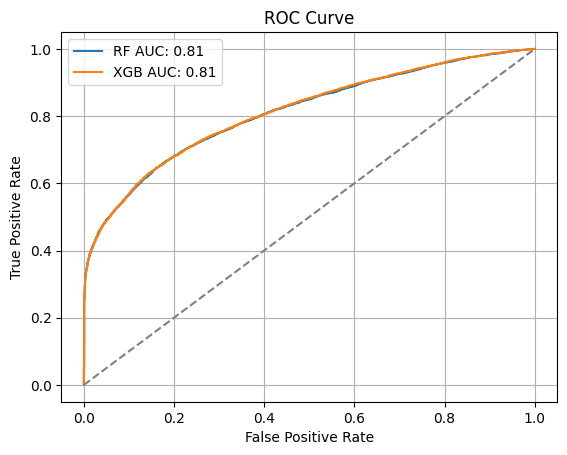

In [13]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test_cls, rf_class), annot=True, fmt='d')
plt.title("RF Confusion Matrix")

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test_cls, xgb_class), annot=True, fmt='d')
plt.title("XGB Confusion Matrix")
plt.show()

fpr_rf, tpr_rf, _ = roc_curve(y_test_cls, rf_preds)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_cls, xgb_preds)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"RF AUC: {roc_auc_score(y_test_cls, rf_preds):.2f}")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB AUC: {roc_auc_score(y_test_cls, xgb_preds):.2f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# Show which features were most important

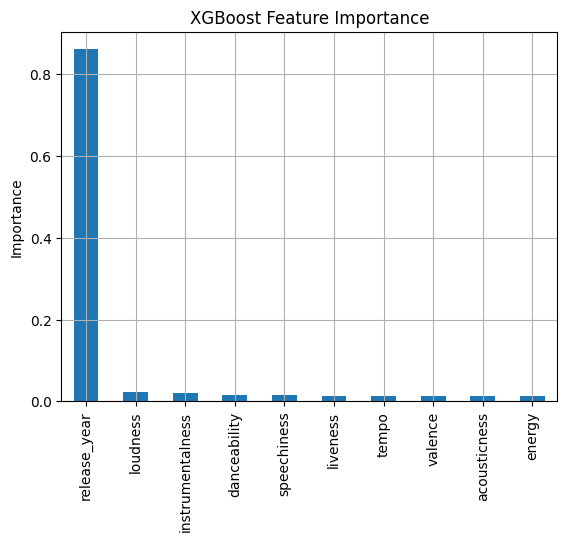

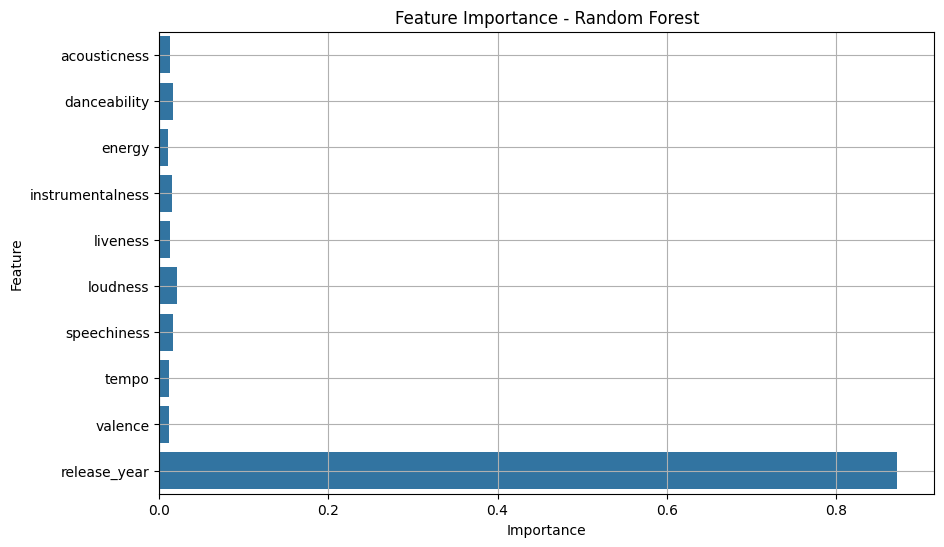

In [14]:
feat_imp = pd.Series(best_xgb.feature_importances_, index=features).sort_values(ascending=False)
plt.figure()
feat_imp.plot(kind='bar')
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.grid(True)
plt.show()

importances = best_rf.feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()


# Add predicted popularity to the dataset

In [15]:
df['predicted_popularity'] = best_xgb.predict(X)


# Build Hybrid Recommendation Engine

In [16]:
def get_user_preferences():
    print("Tell us your music vibe!")
    mood = input("Mood (happy / chill / sad / hype): ").strip().lower()
    tempo = input("Tempo (slow / medium / fast): ").strip().lower()
    danceable = input("Danceable? (yes / no): ").strip().lower()
    era = input("Release Era (90s / 2000s / 2010s / any): ").strip().lower()
    style = input("Style (acoustic / electronic): ").strip().lower()
    return mood, tempo, danceable, era, style


In [17]:
def filter_dataset(mood, tempo, danceable, era, style):
    df_filtered = df_sampled.copy()

    
    if mood == "happy":
        df_filtered = df_filtered[(df_filtered['valence'] > 0.6) & (df_filtered['energy'] > 0.5)]
    elif mood == "chill":
        df_filtered = df_filtered[(df_filtered['valence'] > 0.4) & (df_filtered['energy'] < 0.5)]
    elif mood == "sad":
        df_filtered = df_filtered[(df_filtered['valence'] < 0.4)]
    elif mood == "hype":
        df_filtered = df_filtered[(df_filtered['energy'] > 0.7)]

    
    ...
    return df_filtered.reset_index(drop=True)


In [18]:
def recommend_by_preference():
    mood, tempo, danceable, era, style = get_user_preferences()
    filtered_df = filter_dataset(mood, tempo, danceable, era, style)

    if filtered_df.empty:
        print("No songs found. Try different vibe.")
        return

   
    chosen_song_index = filtered_df.sample(1, random_state=42).index[0]
    print(f"🎵 Based on your vibe: {filtered_df.iloc[chosen_song_index]['name']}")

    recommendations = hybrid_recommend(chosen_song_index, n=5, alpha=0.7)
    print("\n🎧 Recommended for you:")
    print(recommendations)


In [19]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors

audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                  'liveness', 'loudness', 'speechiness', 'tempo', 'valence']


scaler = MinMaxScaler()
feature_matrix = scaler.fit_transform(df_sampled[audio_features])


nm_model = NearestNeighbors(n_neighbors=11, metric='cosine')
nm_model.fit(feature_matrix)


NearestNeighbors(metric='cosine', n_neighbors=11)

In [20]:

df_sampled['predicted_popularity'] = df_sampled['popularity'] + np.random.normal(0, 5, size=len(df_sampled))

In [23]:
recommend_by_preference()

Tell us your music vibe!
🎵 Based on your vibe: Up To You

🎧 Recommended for you:
                                                   name release_date  \
3670                             Shake, Rattle And Roll   2055-12-19   
8354                                   Palabras Tristes   1984-01-01   
3357  Addictive Love - Different Lifestyles Album Ve...   1991-01-01   
4624                                         Cobrastyle   2004-08-18   
2068            You Know What It Is (feat. Wyclef Jean)   2007-06-12   

      popularity  predicted_popularity  
3670          52             56.931528  
8354          51             53.229397  
3357          45             52.156021  
4624          58             51.679879  
2068          45             35.232834  
